In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Total messages sent: 6860
Total messages processed by device 3: 6860
Difference between sent and processed by device 3: 0
Total messages processed by device 4: 6860
Difference between sent and processed by device 4: 0
Total messages processed by device 5: 6860
Difference between sent and processed by device 5: 0
Total messages processed by device 6: 6860
Difference between sent and processed by device 6: 0
Total messages processed by device 7: 6860
Difference between sent and processed by device 7: 0
      index  Sending_Timestamp  Receiving_Timestamp  twin_id  message_id  \
0         0      1782991040756        1782991040757        0         0.0   
1         1      1782991040856        1782991040857        0         1.0   
2         2      1782991040956        1782991040957        0         2.0   
3         3      1782991041056        1782991041057        0         3.0   
4         4      1782991041156        1782991041157        0         4.0   
...     ...                ...        

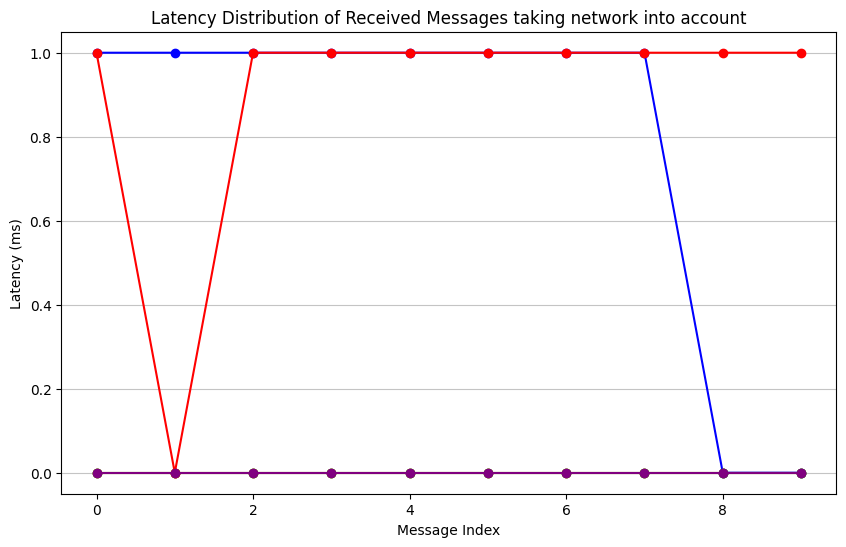

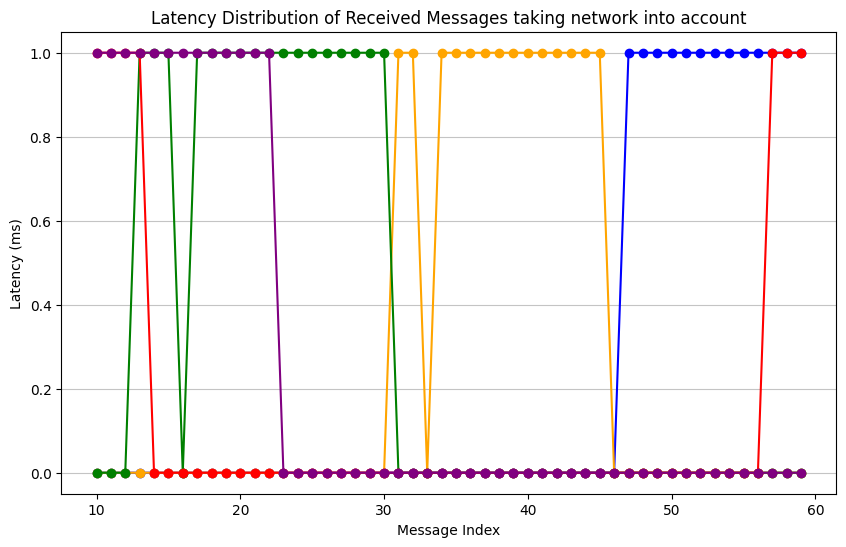

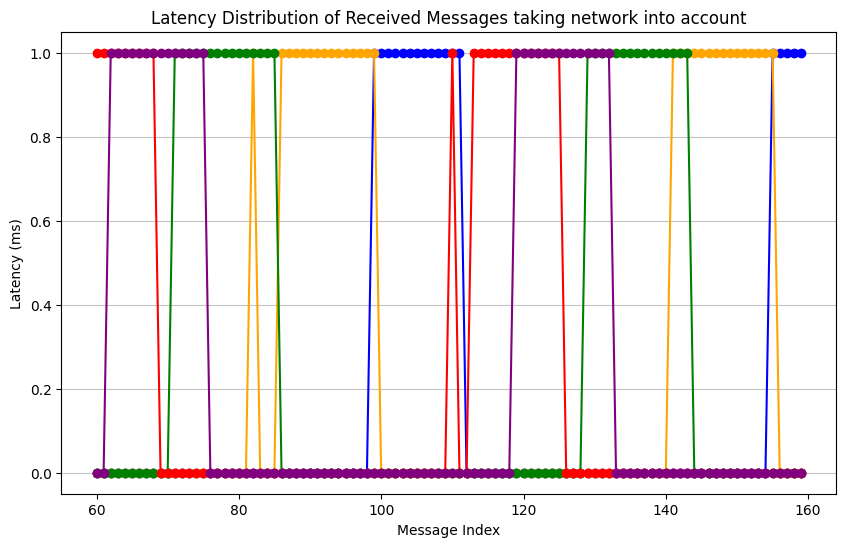

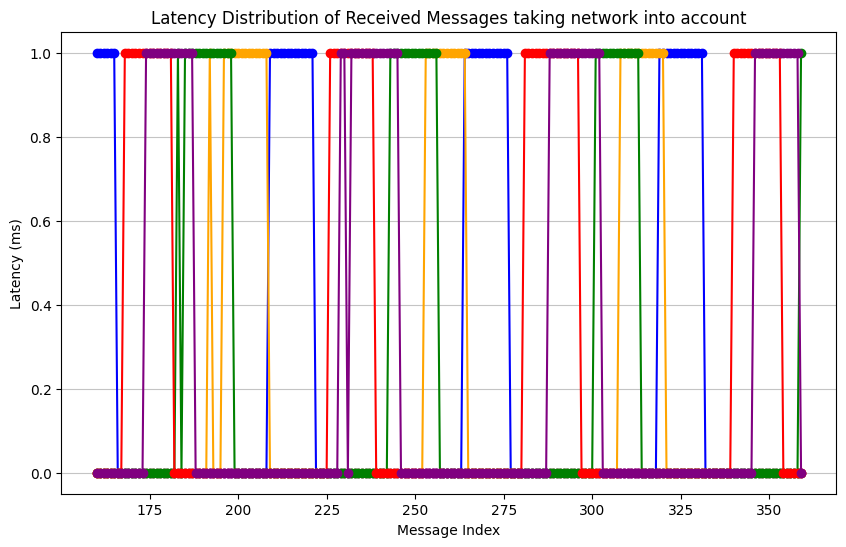

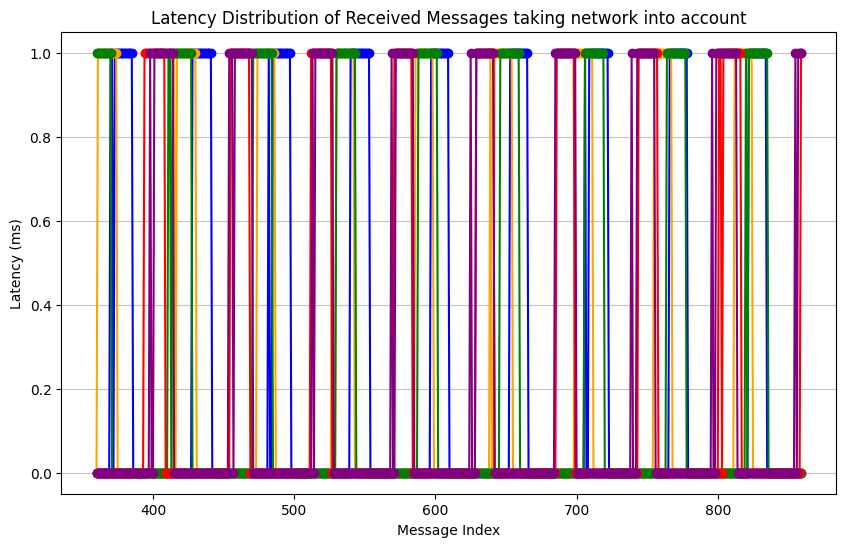

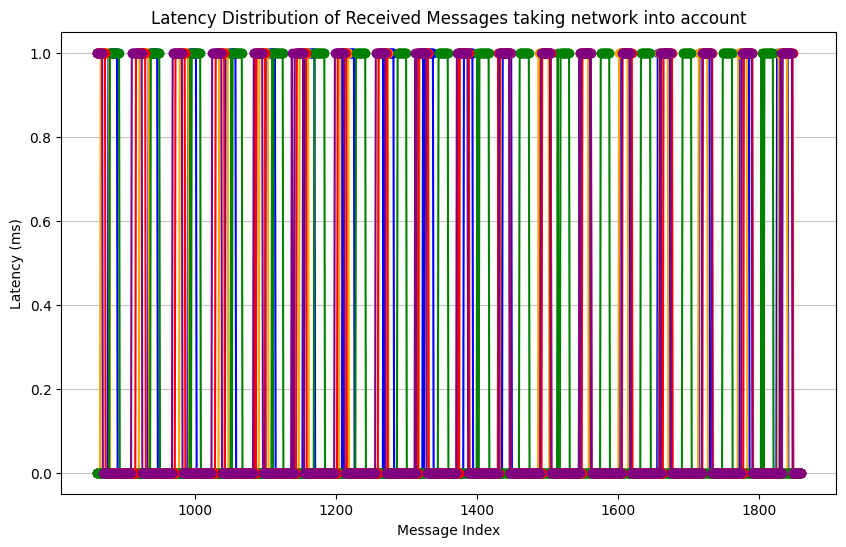

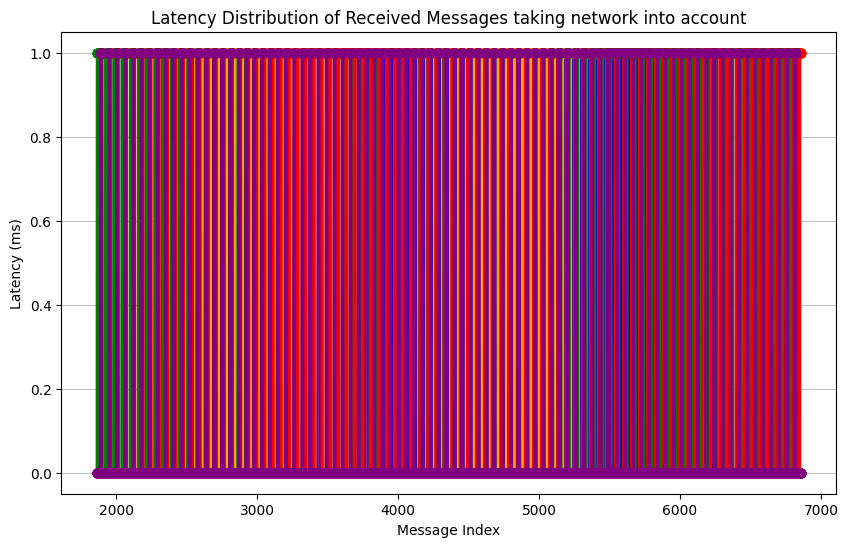

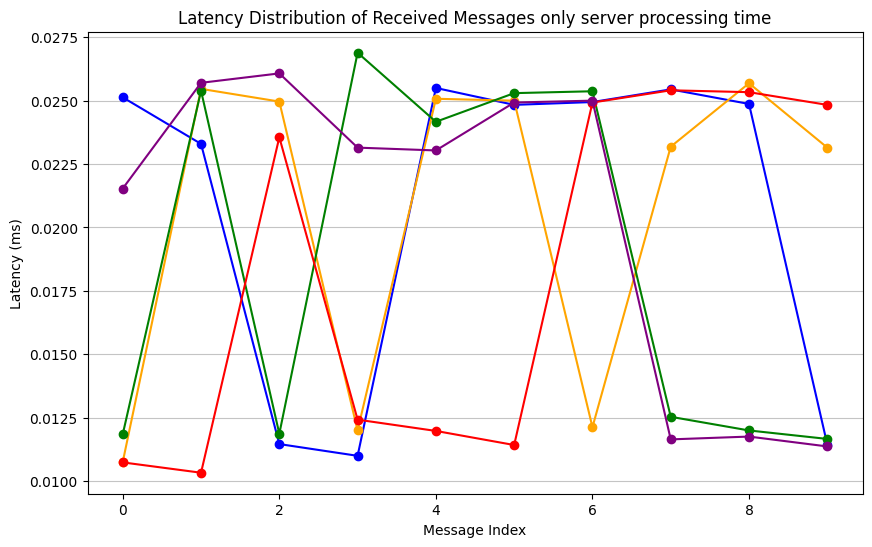

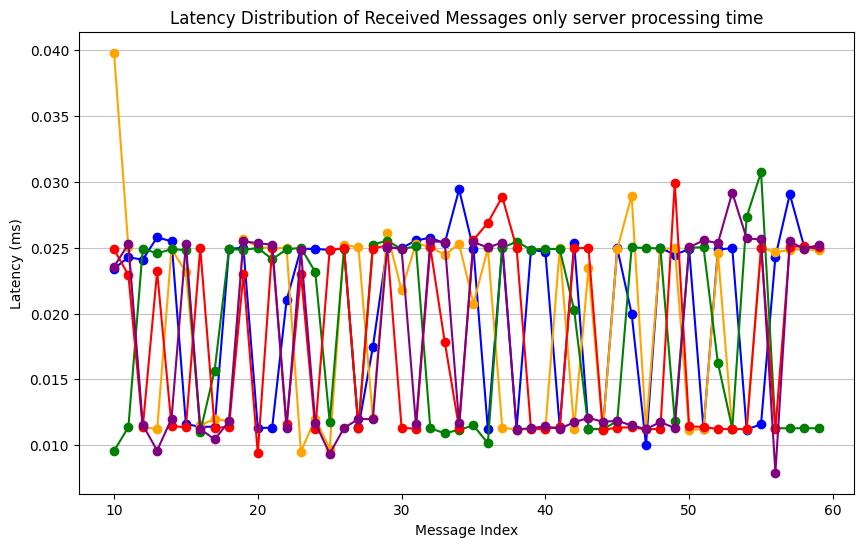

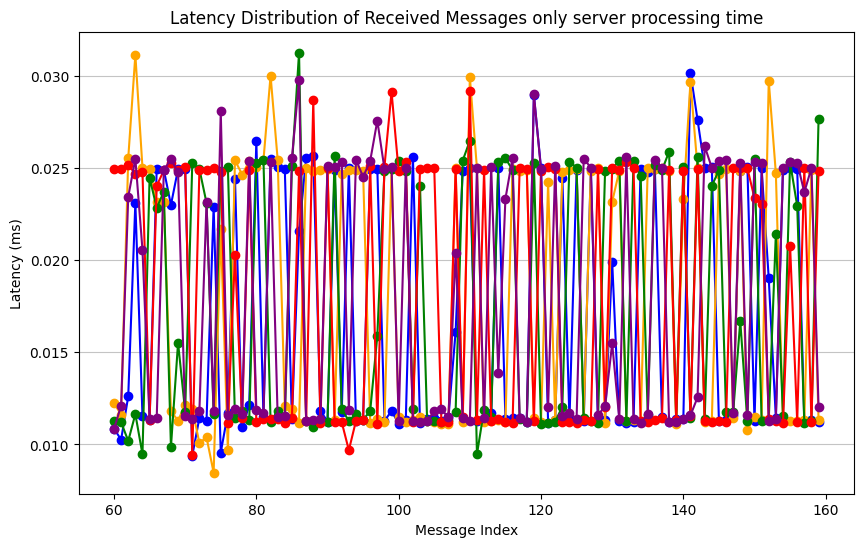

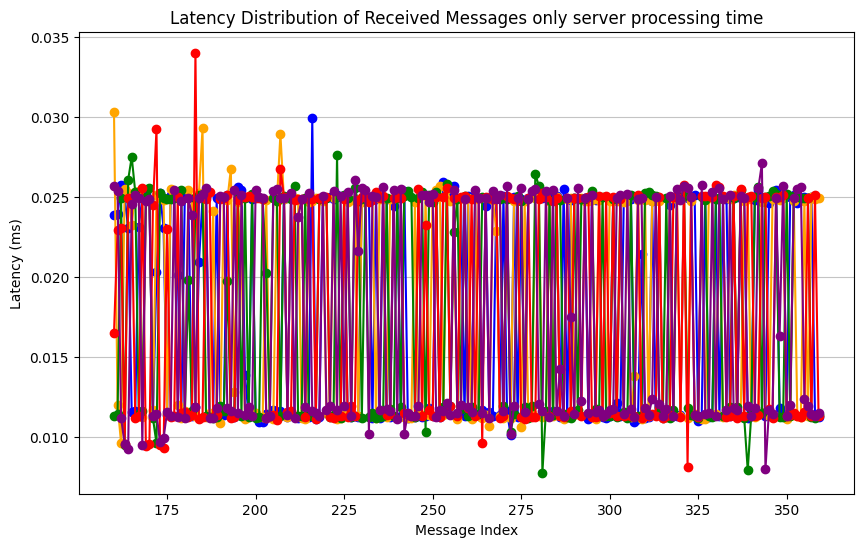

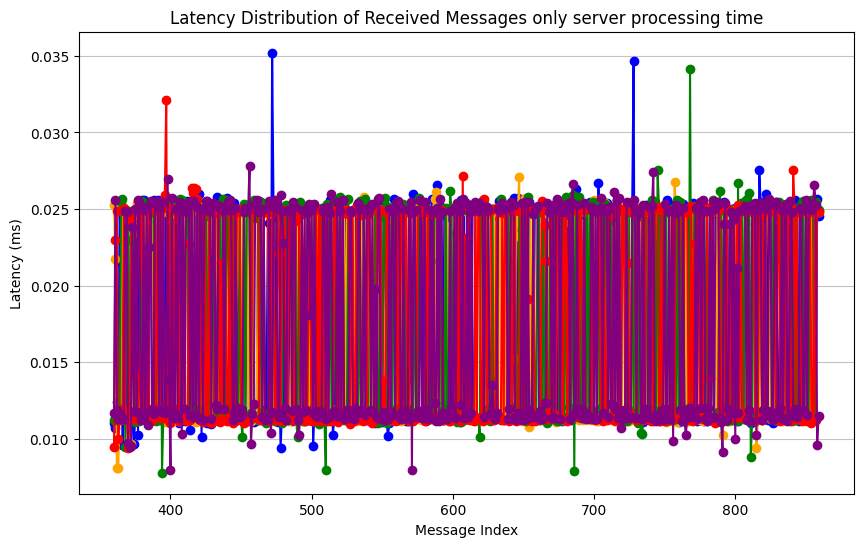

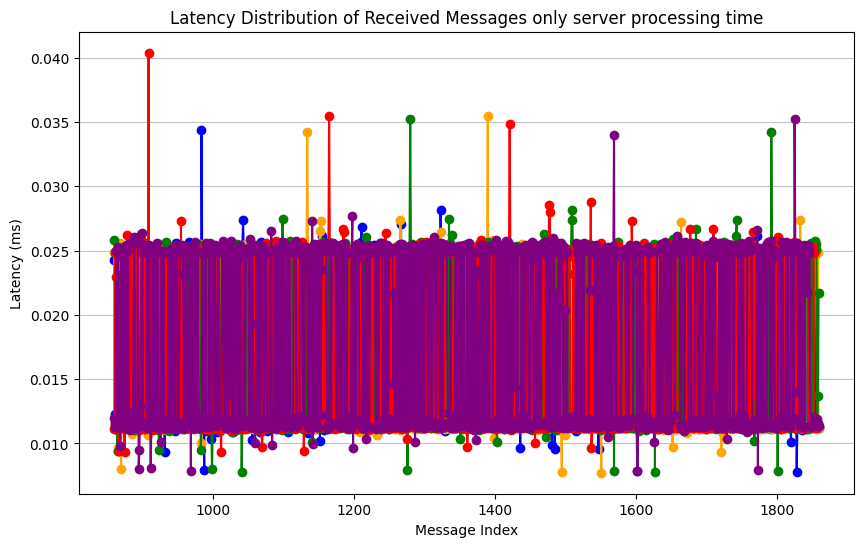

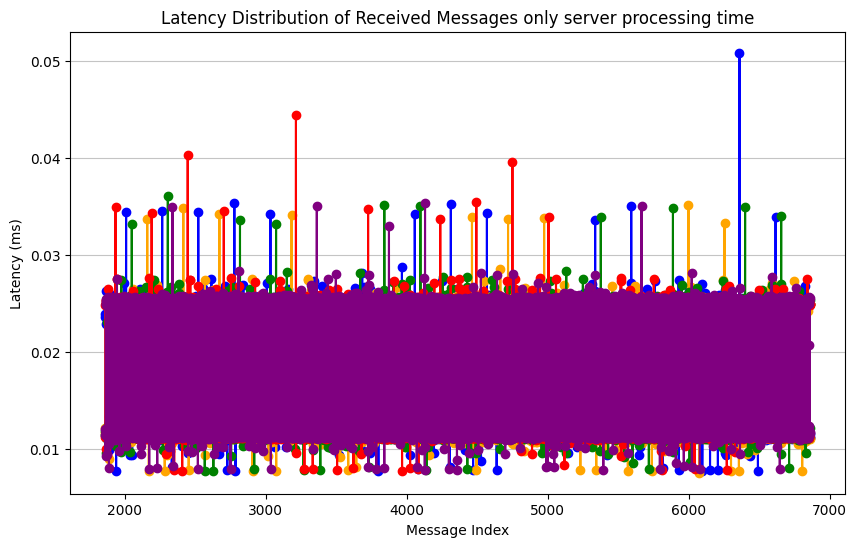

In [5]:
df_3 = pd.read_csv('mensajes_recibido-rbpi3.csv')
df_4 = pd.read_csv('mensajes_recibido-rbpi4.csv')
df_5 = pd.read_csv('mensajes_recibido-rbpi5.csv')
df_6 = pd.read_csv('mensajes_recibido-rbpi6.csv')
df_7 = pd.read_csv('mensajes_recibido-rbpi7.csv')


df_3.reset_index(inplace=True)
df_4.reset_index(inplace=True)
df_5.reset_index(inplace=True)
df_6.reset_index(inplace=True)
df_7.reset_index(inplace=True)



pruebas = [10, 50, 100, 200, 500, 1000, 5000]
lista = []
contador = 0
for prueba in pruebas:
    for i in range(0, prueba):
        lista.append(prueba)
        contador += 1




df_3['grupo'] = lista   
df_4['grupo'] = lista   
df_5['grupo'] = lista   
df_6['grupo'] = lista   
df_7['grupo'] = lista

print("Total messages sent:", sum(pruebas))
print("Total messages processed by device 3:", df_3.shape[0])
print("Difference between sent and processed by device 3:", sum(pruebas) - df_3.shape[0])
print("Total messages processed by device 4:", df_4.shape[0])
print("Difference between sent and processed by device 4:", sum(pruebas) - df_4.shape[0])
print("Total messages processed by device 5:", df_5.shape[0])
print("Difference between sent and processed by device 5:", sum(pruebas) - df_5.shape[0])
print("Total messages processed by device 6:", df_6.shape[0])
print("Difference between sent and processed by device 6:", sum(pruebas) - df_6.shape[0])
print("Total messages processed by device 7:", df_7.shape[0])
print("Difference between sent and processed by device 7:", sum(pruebas) - df_7.shape[0])



fdf = pd.read_csv('resultados_experimento.csv')
ldf = pd.read_csv('resultados_experimento2.csv')



joined_df = pd.merge(fdf, ldf, on=['value', 'twin_id'], suffixes=('_arrived', '_leaving'))

cut_df_for3 = joined_df[joined_df['twin_id'] == 0]
cut_df_for4 = joined_df[joined_df['twin_id'] == 1]
cut_df_for5 = joined_df[joined_df['twin_id'] == 2]
cut_df_for6 = joined_df[joined_df['twin_id'] == 3]
cut_df_for7 = joined_df[joined_df['twin_id'] == 4]

df_3 = pd.merge(df_3, cut_df_for3, left_on=['message_id', 'twin_id'], right_on=['value', 'twin_id'])
df_4 = pd.merge(df_4, cut_df_for4, left_on=['message_id', 'twin_id'], right_on=['value', 'twin_id'])
df_5 = pd.merge(df_5, cut_df_for5, left_on=['message_id', 'twin_id'], right_on=['value', 'twin_id'])
df_6 = pd.merge(df_6, cut_df_for6, left_on=['message_id', 'twin_id'], right_on=['value', 'twin_id'])
df_7 = pd.merge(df_7, cut_df_for7, left_on=['message_id', 'twin_id'], right_on=['value', 'twin_id'])

print(df_3)


df_3['latency'] = df_3['Receiving_Timestamp'] - df_3['Sending_Timestamp']
df_4['latency'] = df_4['Receiving_Timestamp'] - df_4['Sending_Timestamp']
df_5['latency'] = df_5['Receiving_Timestamp'] - df_5['Sending_Timestamp']
df_6['latency'] = df_6['Receiving_Timestamp'] - df_6['Sending_Timestamp']
df_7['latency'] = df_7['Receiving_Timestamp'] - df_7['Sending_Timestamp']

df_3['latency-s-s'] = (df_3['timestamp_ns_leaving'] - df_3['timestamp_ns_arrived'])/1000000
df_4['latency-s-s'] = (df_4['timestamp_ns_leaving'] - df_4['timestamp_ns_arrived'])/1000000
df_5['latency-s-s'] = (df_5['timestamp_ns_leaving'] - df_5['timestamp_ns_arrived'])/1000000
df_6['latency-s-s'] = (df_6['timestamp_ns_leaving'] - df_6['timestamp_ns_arrived'])/1000000
df_7['latency-s-s'] = (df_7['timestamp_ns_leaving'] - df_7['timestamp_ns_arrived'])/1000000
     
     
lista_pruebas_csv = []
     
for prueba in pruebas:
    df2_3 = df_3[df_3['grupo'] == prueba]
    df2_4 = df_4[df_4['grupo'] == prueba]
    df2_5 = df_5[df_5['grupo'] == prueba]
    df2_6 = df_6[df_6['grupo'] == prueba]
    df2_7 = df_7[df_7['grupo'] == prueba]
    
    
    print(df2_3.head())
    mean_latency_3_general = df2_3['latency'].mean()
    mean_latency_4_general = df2_4['latency'].mean()
    mean_latency_5_general = df2_5['latency'].mean()
    mean_latency_6_general = df2_6['latency'].mean()
    mean_latency_7_general = df2_7['latency'].mean()
    
    max_latency_3_general = df2_3['latency'].max()
    max_latency_4_general = df2_4['latency'].max()
    max_latency_5_general = df2_5['latency'].max()
    max_latency_6_general = df2_6['latency'].max()
    max_latency_7_general = df2_7['latency'].max()
    
    mean_latency_3_server = df2_3['latency-s-s'].mean()
    mean_latency_4_server = df2_4['latency-s-s'].mean()
    mean_latency_5_server = df2_5['latency-s-s'].mean()
    mean_latency_6_server = df2_6['latency-s-s'].mean()
    mean_latency_7_server = df2_7['latency-s-s'].mean()
    
    max_latency_3_server = df2_3['latency-s-s'].max()
    max_latency_4_server = df2_4['latency-s-s'].max()
    max_latency_5_server = df2_5['latency-s-s'].max()
    max_latency_6_server = df2_6['latency-s-s'].max()
    max_latency_7_server = df2_7['latency-s-s'].max()
    
    lista_pruebas_csv.append({
        'prueba': prueba,
        'mean_latency_3_general': mean_latency_3_general,
        'mean_latency_4_general': mean_latency_4_general,
        'mean_latency_5_general': mean_latency_5_general,
        'mean_latency_6_general': mean_latency_6_general,
        'mean_latency_7_general': mean_latency_7_general,
        'max_latency_3_general': max_latency_3_general,
        'max_latency_4_general': max_latency_4_general,
        'max_latency_5_general': max_latency_5_general,
        'max_latency_6_general': max_latency_6_general,
        'max_latency_7_general': max_latency_7_general,
        'mean_latency_3_server': mean_latency_3_server,
        'mean_latency_4_server': mean_latency_4_server,
        'mean_latency_5_server': mean_latency_5_server,
        'mean_latency_6_server': mean_latency_6_server,
        'mean_latency_7_server': mean_latency_7_server,
        'max_latency_3_server': max_latency_3_server,
        'max_latency_4_server': max_latency_4_server,
        'max_latency_5_server': max_latency_5_server,
        'max_latency_6_server': max_latency_6_server,
        'max_latency_7_server': max_latency_7_server
    })
    
    
    
    
    
    plt.figure(figsize=(10, 6))
    plt.plot(df2_3['index'], df2_3['latency'], marker='o', linestyle='-', color='blue')
    plt.plot(df2_4['index'], df2_4['latency'], marker='o', linestyle='-', color='orange')
    plt.plot(df2_5['index'], df2_5['latency'], marker='o', linestyle='-', color='green')
    plt.plot(df2_6['index'], df2_6['latency'], marker='o', linestyle='-', color='red')
    plt.plot(df2_7['index'], df2_7['latency'], marker='o', linestyle='-', color='purple')
    # plt.hist(df[df2_3]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages taking network into account')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_{prueba}.png')
    
lista_pruebas_df = pd.DataFrame(lista_pruebas_csv)
lista_pruebas_df.to_csv('latency_summary_new_ot.csv', index=False)

for prueba in pruebas:
    df2_3 = df_3[df_3['grupo'] == prueba]
    df2_4 = df_4[df_4['grupo'] == prueba]
    df2_5 = df_5[df_5['grupo'] == prueba]
    df2_6 = df_6[df_6['grupo'] == prueba]
    df2_7 = df_7[df_7['grupo'] == prueba]
    
    plt.figure(figsize=(10, 6))
    plt.plot(df2_3['index'], df2_3['latency-s-s'], marker='o', linestyle='-', color='blue')
    plt.plot(df2_4['index'], df2_4['latency-s-s'], marker='o', linestyle='-', color='orange')
    plt.plot(df2_5['index'], df2_5['latency-s-s'], marker='o', linestyle='-', color='green')
    plt.plot(df2_6['index'], df2_6['latency-s-s'], marker='o', linestyle='-', color='red')
    plt.plot(df2_7['index'], df2_7['latency-s-s'], marker='o', linestyle='-', color='purple')
    # plt.hist(df[df2_3]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages only server processing time')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_s_s_{prueba}.png')

# print("Total messages processed:", contador)
# print("Total messages dropped:", sum(pruebas) - contador)


